In [1]:
import os
import argparse

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb

from datatree import open_datatree
from scipy.stats import describe

from var_assim.plotting.presets import get_presets
from var_assim.plotting.bias_perc_error_over_time import make_cleaned_datatree_list
from var_assim.plotting.filtering import filter_by_max_conceivable
from var_assim.plotting.pproc import get_angle_r2, get_angles_for_dt_list
from var_assim.config import PRIOR_PATH, NOISE_PATH, TRUTH_PATH, WINDOW_PATH
from var_assim.calibration.priors import ClimateModelPriors
from var_assim.calibration.noise import ClimateModelNoise
from var_assim.calibration.truth import ClimateModelTruth
from var_assim.calibration.windowing import AssimilationWindowing

In [2]:
presets, basefile = get_presets()
plt.rcParams.update(presets)
SAVE_FIGS = True

In [3]:
# simulation config
cwd = os.getcwd()
prefix = 'margobs_ws'
ssp = 'ssp245'
model = 'pco2geowc'
reg_noise = False
TMIN = 2025
AR = '1'
angles_file = ['9', '12', '14', '17', '21', '33']
ECS = 3.0
DEGpDEC = '0.1'
NYRSRAMP = 50
Nwinds = '14custom'
windowing_config = 'original'
Nens = 500

# import files and convert to datatrees
if model == 'pco2geowc_nn':
    fnames = [
        cwd + '/../../data/output/' + model + '/'
        + prefix + '_' + ssp + '_' + model + '_TMIN' + str(TMIN) + '_THETA' + th + '_ECS' + str(ECS)
        + '_DEGpDEC' + DEGpDEC + '_NYRSRAMP' + str(NYRSRAMP) + '_Nwinds' + Nwinds + '_Nens' + str(Nens) + '.nc'
        for th in angles_file
    ]

else:    
    fnames = [
        cwd + '/../../data/output/' + model + '/'
        + prefix + '_' + ssp + '_' + model + '_TMIN' + str(TMIN) + '_AR' + AR + '_THETA' + th + '_ECS' + str(ECS)
        + '_DEGpDEC' + DEGpDEC + '_NYRSRAMP' + str(NYRSRAMP) + '_Nwinds' + Nwinds + '_Nens' + str(Nens) + '.nc'
        for th in angles_file
    ]

In [4]:
cli_args = argparse.Namespace(
    model=model,
    ssp=ssp,
    noise_model=f"AR{AR}" if model != 'pco2geowc_nn' else 'nn',
    tmin=TMIN,
    AR=AR,
    ECS=ECS,
    DEGpDEC=DEGpDEC,
    NYRSRAMP=NYRSRAMP,
    Nwinds=Nwinds,
    Nens=Nens,
    reg_noise=reg_noise,
    windowing=windowing_config
)

Noise = ClimateModelNoise.from_cli_and_yaml(cli_args, NOISE_PATH)
Prior = ClimateModelPriors.from_cli_and_yaml_and_noise(cli_args, PRIOR_PATH, Noise)
Windowing = AssimilationWindowing.from_cli_and_yaml(cli_args, WINDOW_PATH)

In [5]:
dt_meta = open_datatree(fnames[0], engine='netcdf4')

In [6]:
relevant_vars = ['cost_hist', 'controls', 'controls_hist']
all_vars = [x for x in dt_meta['2027'].ds.data_vars]
dropped_vars = [v for v in all_vars if v not in relevant_vars]
dropped_vars


['data_final',
 'l2s',
 'costs',
 'data_hist',
 'l2_hist',
 'flag',
 'obs',
 'data_truth',
 'controls_truth']

In [7]:
dts_clean = make_cleaned_datatree_list(fnames, angles_file, dropped_vars, THRESHOLD=1e-2)

Processing angle = 9...
Found 15 nodes in tree
Processing node 1: /2027
  Memory: 7.4 MB
  Result: 500 kept, 0 filtered
Processing node 2: /2029
  Memory: 8.2 MB
  Result: 494 kept, 6 filtered
Processing node 3: /2031
  Memory: 9.0 MB
  Result: 499 kept, 1 filtered
Processing node 4: /2033
  Memory: 9.7 MB
  Result: 496 kept, 4 filtered
Processing node 5: /2035
  Memory: 10.5 MB
  Result: 498 kept, 2 filtered
Processing node 6: /2037
  Memory: 11.3 MB
  Result: 487 kept, 13 filtered
Processing node 7: /2039
  Memory: 12.1 MB
  Result: 491 kept, 9 filtered
Processing node 8: /2041
  Memory: 12.8 MB
  Result: 493 kept, 7 filtered
Processing node 9: /2043
  Memory: 13.6 MB
  Result: 493 kept, 7 filtered
Processing node 10: /2045
  Memory: 14.4 MB
  Result: 489 kept, 11 filtered
Processing node 11: /2047
  Memory: 15.2 MB
  Result: 487 kept, 13 filtered
Processing node 12: /2049
  Memory: 16.0 MB
  Result: 493 kept, 7 filtered
Processing node 13: /2075
  Memory: 26.1 MB
  Result: 491 kept,

In [8]:
# important simulation constants
L_CEN = Prior.L_CEN
G_CEN = Prior.G_CEN
EPS_CEN = Prior.EPS_CEN
F_EFF_GEO = 0.09  # hard constant
ALPHA_R1_CEN = Prior.ALPHA_CEN[0]
ALPHA_R2_CEN = Prior.ALPHA_CEN[1]

In [9]:
dat = dts_clean[0]

In [10]:
angles_tr = np.zeros(6)

for idx, angle in enumerate(angles_file):
    tmp_cli = argparse.Namespace(
        model=model,
        ssp=ssp,
        noise_model=f"AR{AR}" if model != 'pco2geowc_nn' else 'nn',
        TMIN=TMIN,
        theta=float(angle),
        AR=AR,
        ecs=ECS,
        DEGpDEC=DEGpDEC,
        NYRSRAMP=NYRSRAMP,
        Nwinds=Nwinds,
        Nens=Nens,
        reg_noise=reg_noise
    )
    tmp_truth = ClimateModelTruth.from_cli_and_yaml(tmp_cli, TRUTH_PATH)

    angles_tr[idx] = get_angle_r2(
        tmp_truth.ALPHA_TR[0], tmp_truth.ALPHA_TR[1],
        tmp_truth.BETA_TR[0], tmp_truth.BETA_TR[1],
        tmp_truth.L_TR, tmp_truth.EPS_TR, tmp_truth.G_TR
    )

angles_tr

array([ 8.91821011, 11.92773783, 14.85034704, 16.7546802 , 21.13149999,
       33.02569211])

In [11]:
# pull prior distributions
prior_a1 = dat['2027'].ds.controls_hist.sel(vari='ALPHA_R1', iter=0).values
prior_b1 = dat['2027'].ds.controls_hist.sel(vari='BETA_R1', iter=0).values
prior_a2 = dat['2027'].ds.controls_hist.sel(vari='ALPHA_R2', iter=0).values
prior_b2 = dat['2027'].ds.controls_hist.sel(vari='BETA_R2', iter=0).values
prior_l = dat['2027'].ds.controls_hist.sel(vari='L', iter=0).values
prior_g = dat['2027'].ds.controls_hist.sel(vari='G', iter=0).values
prior_eps = dat['2027'].ds.controls_hist.sel(vari='EPS', iter=0).values

# compute priors
angles_prior = np.zeros(Nens)
for i in range(Nens):
    angles_prior[i] = get_angle_r2(prior_a1[i], prior_a2[i], prior_b1[i], prior_b2[i], prior_l[i], prior_eps[i], prior_g[i])

# describe for the people
describe(angles_prior, nan_policy='omit')

DescribeResult(nobs=500, minmax=(2.1498398364124376, 36.999684193011696), mean=14.614054598287966, variance=21.933064203710426, skewness=0.5712376007894195, kurtosis=0.7489433645300116)

In [12]:
winds = np.array([w[1] for w in Windowing.windows])
windss = [str(w) for w in winds]
THRES = 1e-1

In [13]:
angles = get_angles_for_dt_list(dts_clean, windss, Nens)

In [14]:
ANGLE_MAX_CONCEIVABLE = 45. 
angles_filtered = filter_by_max_conceivable(angles, ANGLE_MAX_CONCEIVABLE)
angles_filtered.shape

(6, 14, 500)

Figure saved to /project/bbcael/ambauer/learning_sai/analysis/notebooks/figs/2026-5-20-ens-med-bias-percrange-margobs_ws-ssp245-TMIN2025-AR1-ECS3.0-DEGpDEC0.1-Nwinds14custom-Nens500.png


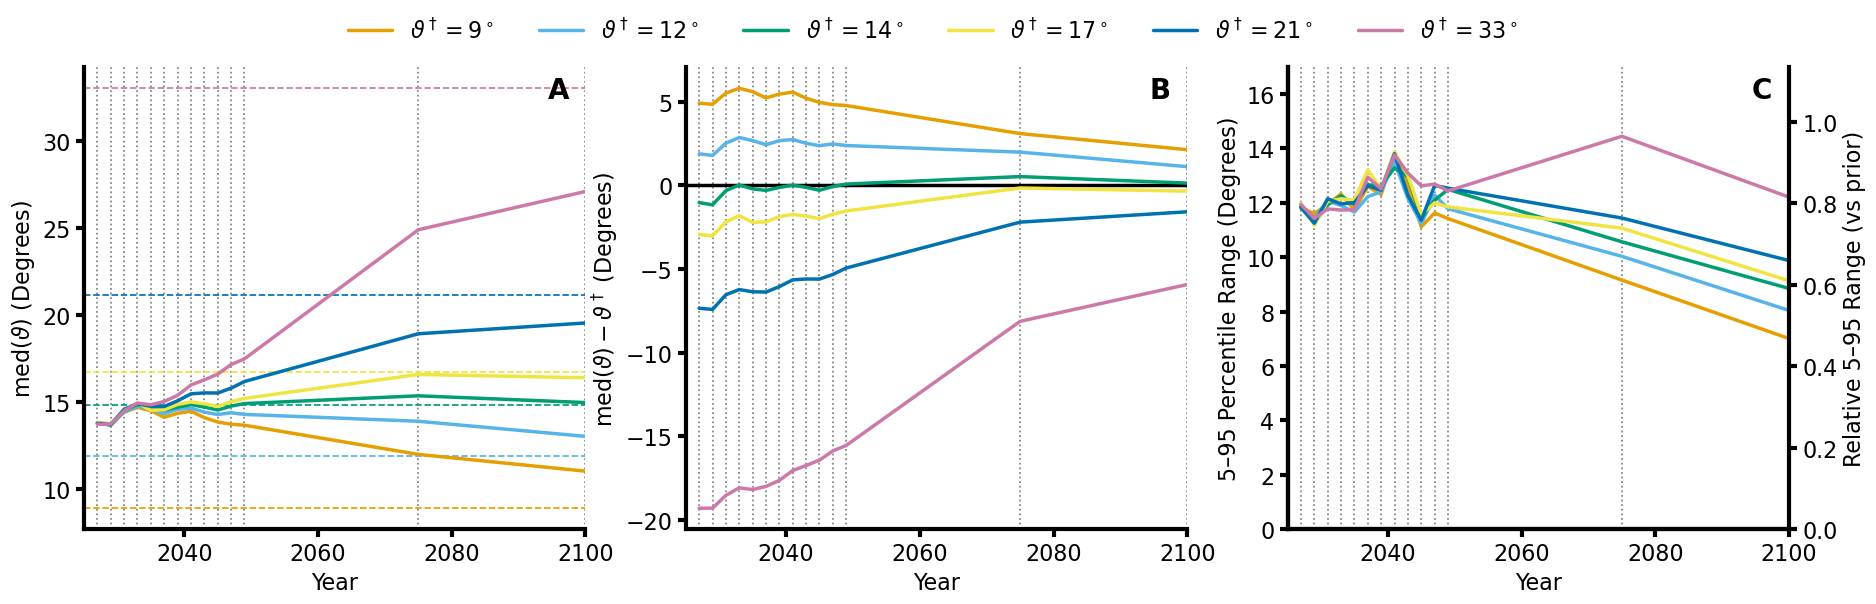

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(22, 6))
color_list = ['#000000', '#E69F00', '#56B4E9', '#009E73', '#F0E442',
              '#0072B2', '#CC79A7', '#D55E00']

YMIN, YMAX = 5, 25
PLO, PHI = 5, 95

for a in ax:
    a.set_xlim((2025, 2100))

for w in winds:
    for a in ax:
        a.axvline(w, linestyle='dotted', color='grey', linewidth=1.25)
        a.set_xlabel("Year")

for i in range(len(angles_file)):
    ax[0].plot(winds, np.nanmedian(angles_filtered[i], axis=1),
               linestyle='solid', color=color_list[i+1],
               label=r'$\vartheta^\dagger=${}$^\circ$'.format(angles_file[i]), zorder=100)

    ax[0].axhline(angles_tr[i], linestyle='dashed', linewidth=1.25, color=color_list[i+1])

    ax[1].plot(winds, np.nanmedian(angles_filtered[i], axis=1) - angles_tr[i], 
           color=color_list[i+1], zorder=100, linestyle='solid')

    ax[2].plot(winds, np.nanpercentile(angles_filtered[i], PHI, axis=1) - np.nanpercentile(angles_filtered[i], PLO, axis=1), 
           label=r'$\vartheta*=${}$^\circ$'.format(angles_file[0]), zorder=100, color=color_list[i+1], linestyle='solid')

ax[0].set_ylabel(r"med$(\vartheta)$ (Degrees)")
ax[0].legend(bbox_to_anchor=(2.9, 1.15), ncols=len(angles_file))

ax[1].set_ylabel(r"med$(\vartheta) - \vartheta^\dagger$ (Degrees)")
ax[1].axhline(0, color='k', linestyle='solid')

ax[2].set_ylabel(f"{PLO}–{PHI} Percentile Range (Degrees)")
ax[2].set_ylim((0, 2 + np.nanpercentile(angles_prior, PHI) - np.nanpercentile(angles_prior, PLO)))

ax2_rel = ax[2].twinx()
ax2_rel.set_ylabel(f"Relative {PLO}–{PHI} Range (vs prior)")
ax2_rel.spines['right'].set_visible(True)
ax2_rel.set_ylim((0, (2 + np.nanpercentile(angles_prior, PHI) - np.nanpercentile(angles_prior, PLO)) / (np.nanpercentile(angles_prior, PHI) - np.nanpercentile(angles_prior, PLO))))

# Add bold, all-caps panel labels
for a, label in zip(ax, ['A', 'B', 'C']):
    a.text(0.925, 0.98, label, transform=a.transAxes,
           fontsize=20, fontweight='bold', va='top', ha='left')

if SAVE_FIGS:
    filename = "ens-med-bias-percrange-{}-{}-TMIN{}-AR{}-ECS{}-DEGpDEC{}-Nwinds{}-Nens{}.png".format(prefix, ssp, TMIN, AR, ECS, DEGpDEC, Nwinds, Nens)
    # fig.savefig(basefile + filename, dpi=350, bbox_inches='tight')
    print("Figure saved to {}".format(basefile + filename))

plt.show()

In [ ]:
describe(angles_filtered[-1, -2][angles_filtered[-1, -2] <= ANGLE_MAX_CONCEIVABLE], nan_policy='omit')

DescribeResult(nobs=484, minmax=(16.03612357872605, 41.54084029520232), mean=25.56763324527773, variance=18.57130613617469, skewness=0.6791982728376174, kurtosis=0.4231107915919816)

In [ ]:
import seaborn as sb
import pandas as pd

In [ ]:
np.hstack([np.arange(2027, 2050, 2), [2075, 2100]])[-2]

In [ ]:
# prepare data for plotting
tr_, yr_ = 2, '2049'  # choose true value index and assimilation year ('obs up to X')
ds = dts[tr_][yr_].ds

angles_sel = angles[tr_, -3]

data = np.zeros((13, Nens))
data[0] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='L').values)
data[1] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='G').values)
data[2] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='EPS').values)
data[3] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='C1').values)
data[4] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='C2').values)
data[5] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='F1_CO2').values)
data[6] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='ALPHA_R1').values)
data[7] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='ALPHA_R2').values)
data[8] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='BETA_R1').values/0.09)
data[9] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='BETA_R2').values/0.09)
data[10] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, angles_sel)
data[11] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, data[5] / data[0])
data[12] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, data[5] / (data[0] + data[1] * data[2]))

In [ ]:
df_all = pd.DataFrame(data=data.T,
    columns=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)', r'$\varepsilon$ ($-$)', r'$C_1$', r'$C_2$',
             r'$f^{(CO_2)}_1$ (W m$^{-2})$', r'$\alpha_{R1}$ ($-$)', r'$\alpha_{R2}$ ($-$)',
             r'$\beta_{R1}$ (K / W m$^{-2}$)', r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta$ (Degrees)', 'ECS (K)', 'TCR (K)']
)

In [ ]:
df_all

In [ ]:
from scipy import stats
# Assuming your dataframe is called 'df'
theta_col = r'$\vartheta$ (Degrees)'

# Get the independent variable (theta)
theta = df_all[theta_col]

results = {}
r_tot = 0

# Loop through each column
for col in df_all.columns:
    # Skip the theta column itself
    if col == theta_col or col == 'ECS (K)' or col == 'TCR (K)':
        continue
    
    # Get the dependent variable
    y = df_all[col]
    
    # Remove NaN values
    mask = ~(np.isnan(theta) | np.isnan(y))
    theta_clean = theta[mask]
    y_clean = y[mask]
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        theta[mask], y[mask]
    )

    r_tot += r_value**2
    
    results[col] = {
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_value**2,
        'p_value': p_value,
        'std_err': std_err
    }

# Convert to DataFrame and sort by R² (descending)
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('r_squared', ascending=False)

print(results_df)
print(f"\n\nVariables ranked by variance explained (R²):")
print("="*60)
for i, (var, row) in enumerate(results_df.iterrows(), 1):
    print(f"{i}. {var}")
    print(f"   R² = {row['r_squared']/r_tot:.4f} ({row['r_squared']*100/r_tot:.2f}% variance explained)")
    print(f"   Slope = {row['slope']:.4f}, p-value = {row['p_value']:.4e}\n")

In [ ]:
pp = sb.pairplot(df_all,
                diag_kind='kde', corner=True, dropna=True)

In [ ]:

pp = sb.pairplot(df_all, vars=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)',
                               r'$f^{(CO_2)}_1$ (W m$^{-2})$', r'$\beta_{R1}$ (K / W m$^{-2}$)', 
                               r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta$ (Degrees)'],
                 diag_kind='kde', corner=True, dropna=True)

prior_f = np.random.normal(4.58, 0.519, size=500)
prior_samples = [prior_l, prior_g, prior_f, prior_b1/0.09, prior_b2/0.09, angles_prior]
var_truth = [L_CEN, G_CEN, 4.58, 0.018/0.09, -0.018/0.09, angles_tr[tr_]]

# add priors on the diagonals
for i, ax in enumerate(pp.diag_axes):
    x = np.linspace(min(prior_samples[i]), max(prior_samples[i]), 200)
    zeros = np.zeros_like(x)
    
    kde = stats.gaussian_kde(prior_samples[i])

    ax2 = ax.twinx()
    ax2.plot(x, kde(x), 'r-', label='Prior', zorder=-1)
    ax2.axvline(var_truth[i], linestyle='dashed', color='b', label="True value")
    ax2.set_xlim((ax.get_xlim()[0], ax.get_xlim()[1]))
    
    #ax2.fill_between(x, zeros, kde(x), alpha=0.3, color='r', zorder=-1)
    
    ax2.set_ylabel('')
    ax2.set_yticks([])

    if i == 0:
        ax2.plot([2.0], [0], 'k-', label="Posterior")
        ax2.legend(bbox_to_anchor=(2.0, 1.0))

if SAVE_FIGS:
    filename = 'corner-regional.svg'
    # pp.savefig(basefile + filename)

In [ ]:
results_df

In [ ]:
TCRs = np.zeros_like(angles)

w_ = 0
d_ = 0
for dt in dts:
    for w in windss:
        F2x = dt[w].ds.controls.sel(vari='F1_CO2').values
        L = dt[w].ds.controls.sel(vari='L').values
        G = dt[w].ds.controls.sel(vari='G').values
        E = dt[w].ds.controls.sel(vari='EPS').values
        TCRs[d_, w_] = F2x / (L + G * E)
        w_ += 1
    d_ += 1
    w_ = 0

TCRs_filtered = np.where(angles > 40, np.nan, TCRs)

In [ ]:
up = 95
lp = 5
lb = 2
ub = -2

plt.scatter(np.nanpercentile(angles_filtered[0], up, axis=1)[lb:ub] - np.nanpercentile(angles_filtered[0], lp, axis=1)[lb:ub],
            np.nanpercentile(TCRs_filtered[0], up, axis=1)[lb:ub] - np.nanpercentile(TCRs_filtered[0], lp, axis=1)[lb:ub])

plt.scatter(np.nanpercentile(angles_filtered[1], up, axis=1)[lb:ub] - np.nanpercentile(angles_filtered[1], lp, axis=1)[lb:ub],
            np.nanpercentile(TCRs_filtered[1], up, axis=1)[lb:ub] - np.nanpercentile(TCRs_filtered[1], lp, axis=1)[lb:ub])

plt.scatter(np.nanpercentile(angles_filtered[2], up, axis=1)[lb:ub] - np.nanpercentile(angles_filtered[2], lp, axis=1)[lb:ub],
            np.nanpercentile(TCRs_filtered[2], up, axis=1)[lb:ub] - np.nanpercentile(TCRs_filtered[2], lp, axis=1)[lb:ub])

plt.title("Percentile ranges post 2030")
plt.ylabel("TCR 95-5 Percentile Range")
plt.xlabel(r"$\vartheta$ 95-5 Percentile Range")

In [ ]:
np.nanpercentile(angles_filtered[0], 95, axis=1) - np.nanpercentile(angles_filtered[0], 5, axis=1)


In [ ]:
from scipy.stats import describe

describe(angles[0, 2]).mean

In [ ]:
plt.hist(angles_prior)
plt.hist(angles[1, 3])

In [ ]:
angles_filtered = np.where(angles > 40, np.nan, angles)
angles_filtered

In [ ]:
plt.hist(angles_prior)
plt.hist(angles_filtered[1, 3])

In [ ]:
x = ['tat', 'tdo', 'q', 'tr1', 'tr2', 'l', 'g', 'e', 'c1', 'c2', 'f1', 'a1', 'a2', 'b1', 'b2', 'else']

In [ ]:
x


In [ ]:
x[5:13]

In [ ]:
x[5:12]

In [ ]:
x[5:14]

# OLD STUFF THAT IS DEPRECIATED AND / OR WRONG

In [ ]:
# THIS IS OLD AND DEPRECIATED
def get_angle_OLD(a1, b1, a2, b2, a1cent, a2cent, lam, f_eff):
    # convert betas into xis
    prefactor1 = lam / (f_eff * a1cent)
    prefactor2 = lam / (f_eff * a2cent)
    xi1 = b1 * prefactor1
    xi2 = b2 * prefactor2

    # coefficient on SAI contribution to temperature rise
    comp1 = a1cent * (xi1 - 1)
    comp2 = a2cent * (xi2 - 1)

    # angle components
    ang_num = a1 * b1 + a2 * b2
    ang_denom = np.sqrt(
        (a1**2 + a2**2) * (b1**2 + b2**2)
    )
    return np.arccos(ang_num / ang_denom) * 180 / np.pi